In [1]:
# Google Colab setup for Kaggle API

from google.colab import files

!pip install -q kaggle

files.upload()

!mkdir ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


In [2]:
# 1. Download the full zip (it's big, but reliable)
!kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot

# 2. Extract ONLY the DNN-EdgeIIoT-dataset.csv file
# The -j flag flattens the directory structure so it drops right into your current folder
!unzip -j edgeiiotset-cyber-security-dataset-of-iot-iiot.zip "*DNN-EdgeIIoT-dataset.csv" "*ML-EdgeIIoT-dataset.csv" -d .

# 3. Verify it's there
!ls -lh DNN-EdgeIIoT-dataset.csv

Dataset URL: https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot
License(s): CC-BY-NC-SA-4.0
 98% 1.60G/1.63G [00:11<00:00, 37.4MB/s]
100% 1.63G/1.63G [00:11<00:00, 147MB/s] 
Archive:  edgeiiotset-cyber-security-dataset-of-iot-iiot.zip
  inflating: ./DNN-EdgeIIoT-dataset.csv  
  inflating: ./ML-EdgeIIoT-dataset.csv  
-rw-r--r-- 1 root root 1.2G Mar 18  2022 DNN-EdgeIIoT-dataset.csv


In [3]:
import pandas as pd

import numpy as np

df_ml = pd.read_csv('ML-EdgeIIoT-dataset.csv', low_memory=False)
# df_dl = pd.read_csv('DNN-EdgeIIoT-dataset.csv', low_memory=False)

# Standard Preprocessing
Prepprocess the data in accordance to steps outlined in EdgeIIoT paper

In [4]:
import sklearn
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import re


def preprocess(df, output_path=None):
    df = df.copy()

    # Drop columns
    drop_columns = [
        "frame.time", "ip.src_host", "ip.dst_host", "arp.src.proto_ipv4", "arp.dst.proto_ipv4",
        "http.file_data", "http.request.full_uri", "icmp.transmit_timestamp",
        "http.request.uri.query", "tcp.options", "tcp.payload", "tcp.srcport",
        "tcp.dstport", "udp.port", "mqtt.msg"
    ]
    df.drop(drop_columns, axis=1, inplace=True, errors='ignore')

    # Drop NaN and duplicates
    df.dropna(axis=0, how='any', inplace=True)
    df.drop_duplicates(subset=None, keep="first", inplace=True)
    df = shuffle(df, random_state=42)

    # Encode categorical features
    def encode_text_dummy(df, name):
        dummies = pd.get_dummies(df[name])
        for x in dummies.columns:
            dummy_name = f"{name}-{x}"
            df[dummy_name] = dummies[x]
        df.drop(name, axis=1, inplace=True)

    encode_text_dummy(df, 'http.request.method')
    encode_text_dummy(df, 'http.referer')
    encode_text_dummy(df, "http.request.version")
    encode_text_dummy(df, "dns.qry.name.len")
    encode_text_dummy(df, "mqtt.conack.flags")
    encode_text_dummy(df, "mqtt.protoname")
    encode_text_dummy(df, "mqtt.topic")

    # Encode labels
    le = LabelEncoder()
    df['Attack_type'] = le.fit_transform(df['Attack_type'])

    # Create mapping dictionary
    label_map = {idx: label for idx, label in enumerate(le.classes_)}

    # Scale features
    X = df.drop('Attack_type', axis=1)
    y = df['Attack_type']

    scaler = StandardScaler() # Could use Robust Scaling?
    X_scaled = scaler.fit_transform(X)

    df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    df_scaled['Attack_type'] = y.values

    # Handle special characters in column names created from encoding
    df_scaled.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df_scaled.columns]

    # Save
    if output_path:
        df_scaled.to_csv(output_path, index=False)

    return df_scaled, label_map

# df_dl_preprocessed, labels_dl = preprocess(df_dl)
df_ml_preprocessed, labels_ml = preprocess(df_ml)


In [5]:
from sklearn.model_selection import train_test_split
X = df_ml_preprocessed.drop('Attack_type', axis=1)
y = df_ml_preprocessed['Attack_type']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 91317
Val size: 30439
Test size: 30440


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                            precision_score, recall_score, accuracy_score)

def evaluate_models(models, X_train, y_train, X_val, y_val, label_map):
    """
    Train and evaluate multiple models on validation set.

    Parameters:
    -----------
    models : dict
        Dictionary of model_name: model_instance
    X_train : DataFrame or array
        Training features
    y_train : Series or array
        Training labels
    X_val : DataFrame or array
        Validation features
    y_val : Series or array
        Validation labels
    label_map : dict
        Dictionary mapping label indices to names

    Returns:
    --------
    dict : Results dictionary with predictions and confusion matrices
    """
    results = {}
    target_names = [label_map[i] for i in sorted(label_map.keys())]

    for name, model in models.items():
        print(f"\n{'='*80}")
        print(f"Training {name}...")
        print('='*80)

        # Train on full training set
        model.fit(X_train, y_train)

        # Predict on val set
        y_pred = model.predict(X_val)

        # Calculate metrics
        print(f"\n{name} Validation Set Results:")
        print(f"  Accuracy:         {accuracy_score(y_val, y_pred):.4f}")
        print(f"  Precision Macro:  {precision_score(y_val, y_pred, average='macro'):.4f}")
        print(f"  Precision Weight: {precision_score(y_val, y_pred, average='weighted'):.4f}")
        print(f"  Recall Macro:     {recall_score(y_val, y_pred, average='macro'):.4f}")
        print(f"  Recall Weight:    {recall_score(y_val, y_pred, average='weighted'):.4f}")
        print(f"  F1 Macro:         {f1_score(y_val, y_pred, average='macro'):.4f}")
        print(f"  F1 Weight:        {f1_score(y_val, y_pred, average='weighted'):.4f}")

        # Classification report
        print(f"\n{name} Classification Report:")
        print(classification_report(y_val, y_pred, target_names=target_names))

        # Confusion matrix
        cm = confusion_matrix(y_val, y_pred)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names)
        plt.title(f'{name} Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        results[name] = {
            'y_pred': y_pred,
            'confusion_matrix': cm,
            'accuracy': accuracy_score(y_val, y_pred),
            'f1_macro': f1_score(y_val, y_pred, average='macro'),
            'f1_weighted': f1_score(y_val, y_pred, average='weighted')
        }

    print("\n" + "="*80)
    print("EVALUATION COMPLETE")
    print("="*80)

    return results


# Baseline Results:
Standard preprocessing, no hyperparameter tuning, no SMOTE

Using traditional ML models shown to perform well on various kaggle competitions (XGBoost, CatBoost, RandomForest, LightGBM)

In [7]:
!pip install xgboost catboost lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00



Training XGBoost...

XGBoost Validation Set Results:
  Accuracy:         0.9464
  Precision Macro:  0.9398
  Precision Weight: 0.9471
  Recall Macro:     0.9250
  Recall Weight:    0.9464
  F1 Macro:         0.9309
  F1 Weight:        0.9462

XGBoost Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.97      0.94      0.96      1973
            DDoS_HTTP       0.90      0.94      0.92      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.89      0.67      0.77       171
                 MITM       1.00      0.99      0.99        72
               Normal       1.00      1.00      1.00      4820
             Password       0.85      0.82      0.83      1994
        Port_Scanning       0.94      1.00      0.97      1784
           Ransomware       0.9

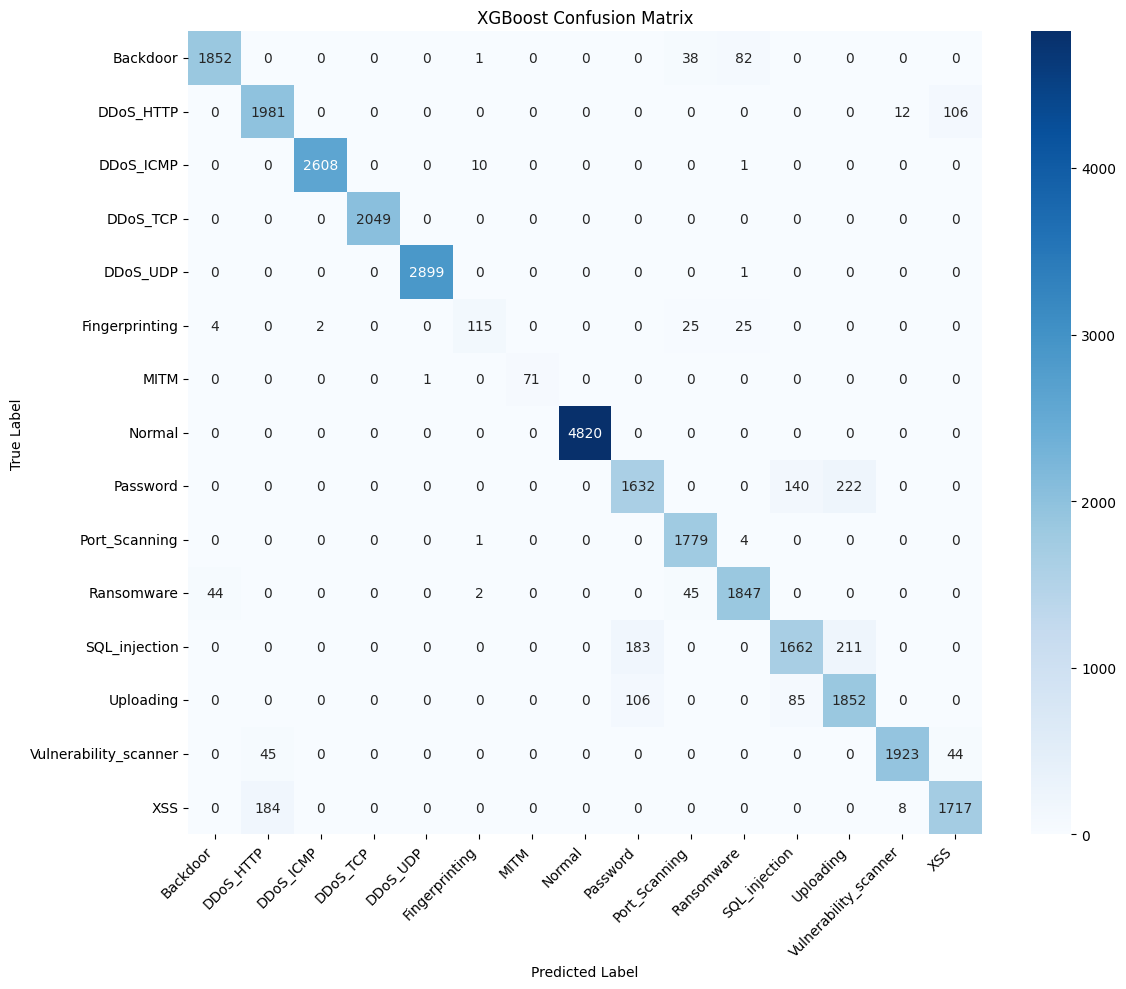


Training CatBoost...

CatBoost Validation Set Results:
  Accuracy:         0.9476
  Precision Macro:  0.9467
  Precision Weight: 0.9486
  Recall Macro:     0.9270
  Recall Weight:    0.9476
  F1 Macro:         0.9346
  F1 Weight:        0.9475

CatBoost Classification Report:
                       precision    recall  f1-score   support

             Backdoor       1.00      0.93      0.96      1973
            DDoS_HTTP       0.90      0.94      0.92      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.98      0.68      0.81       171
                 MITM       1.00      0.99      0.99        72
               Normal       1.00      1.00      1.00      4820
             Password       0.83      0.83      0.83      1994
        Port_Scanning       0.94      1.00      0.97      1784
           Ransomware       

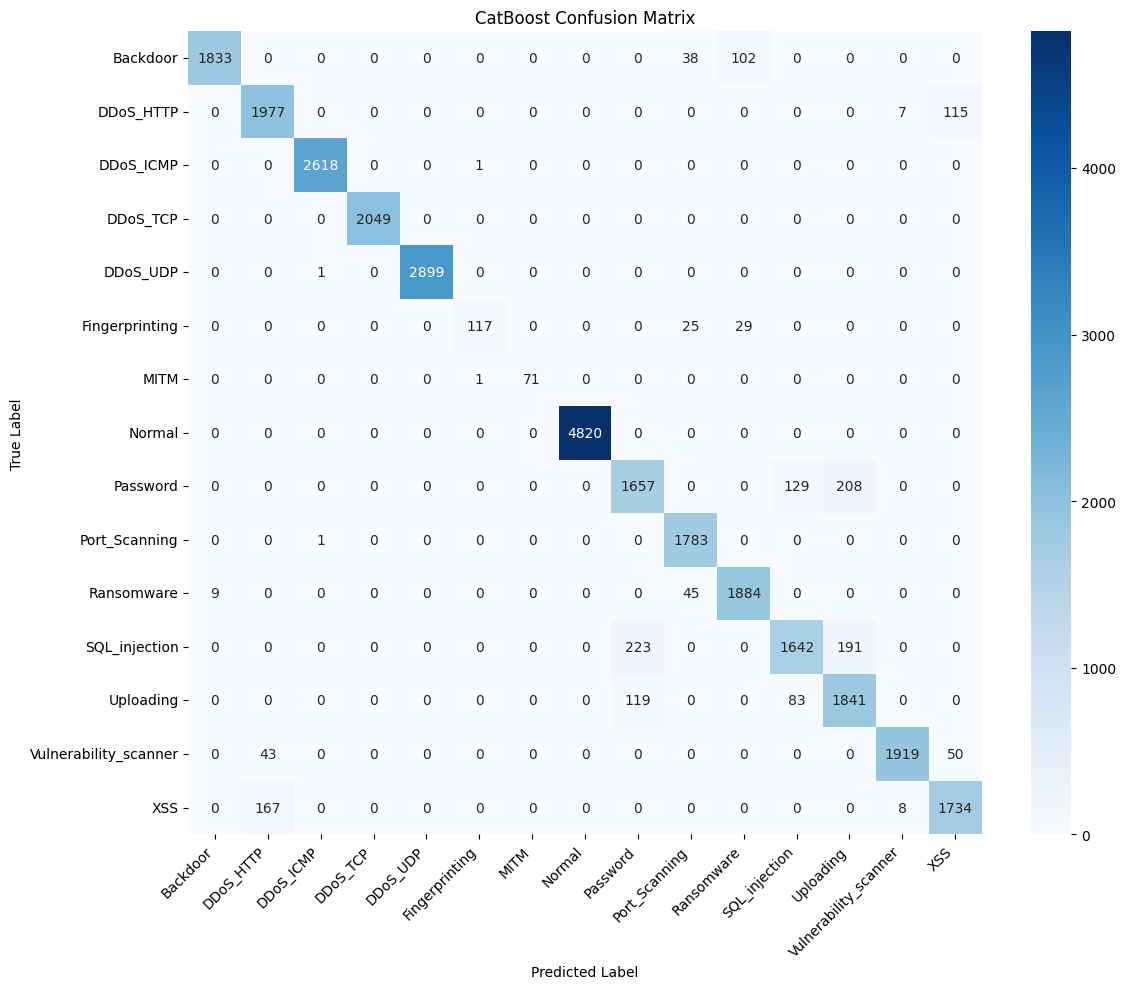


Training LightGBM...

LightGBM Validation Set Results:
  Accuracy:         0.9462
  Precision Macro:  0.9361
  Precision Weight: 0.9469
  Recall Macro:     0.9258
  Recall Weight:    0.9462
  F1 Macro:         0.9299
  F1 Weight:        0.9460

LightGBM Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.97      0.94      0.96      1973
            DDoS_HTTP       0.90      0.95      0.92      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.85      0.69      0.76       171
                 MITM       0.99      0.99      0.99        72
               Normal       1.00      1.00      1.00      4820
             Password       0.85      0.81      0.83      1994
        Port_Scanning       0.94      1.00      0.97      1784
           Ransomware       

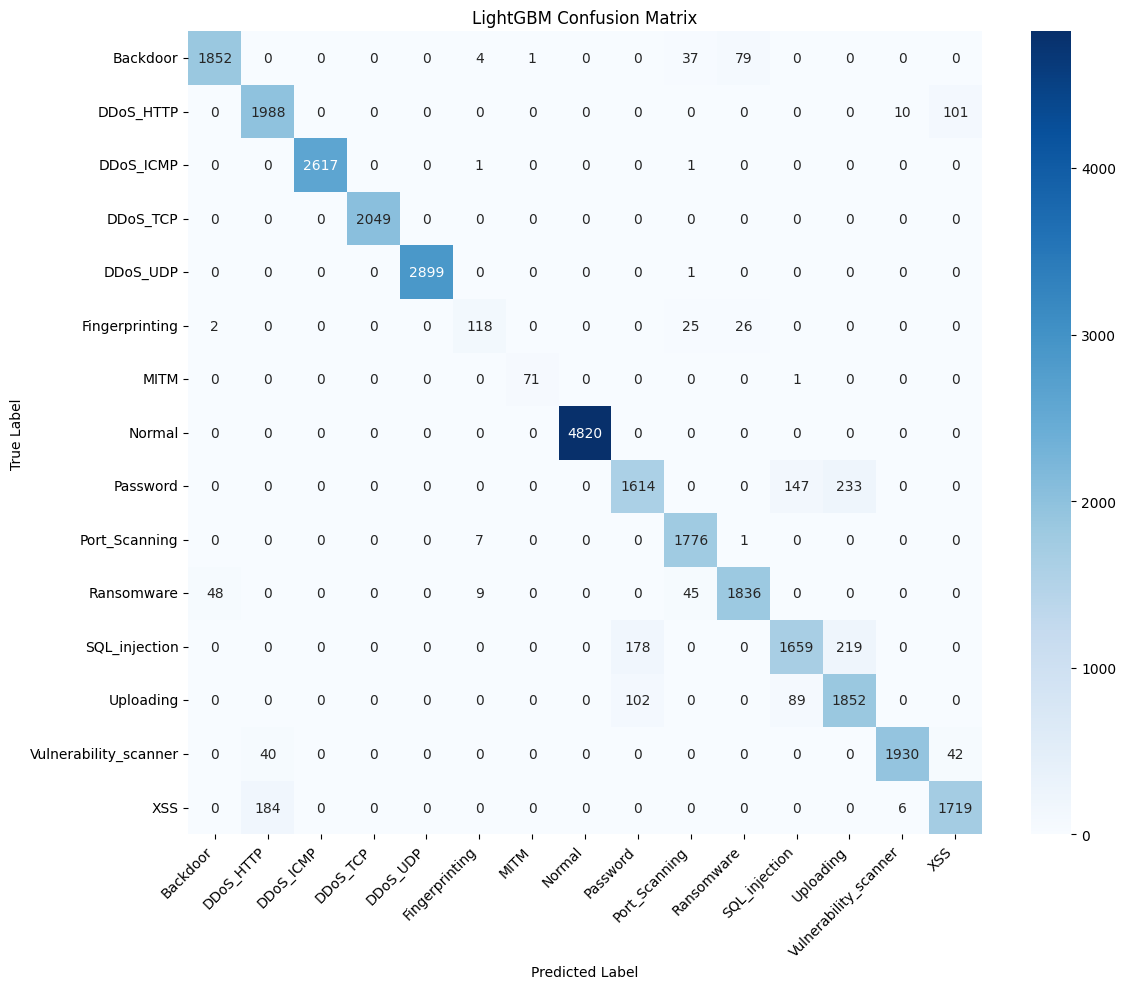


Training RandomForest...

RandomForest Validation Set Results:
  Accuracy:         0.9384
  Precision Macro:  0.9254
  Precision Weight: 0.9386
  Recall Macro:     0.9197
  Recall Weight:    0.9384
  F1 Macro:         0.9223
  F1 Weight:        0.9384

RandomForest Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.96      0.94      0.95      1973
            DDoS_HTTP       0.90      0.89      0.89      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.80      0.70      0.75       171
                 MITM       1.00      1.00      1.00        72
               Normal       1.00      1.00      1.00      4820
             Password       0.81      0.83      0.82      1994
        Port_Scanning       0.94      0.99      0.97      1784
           Ranso

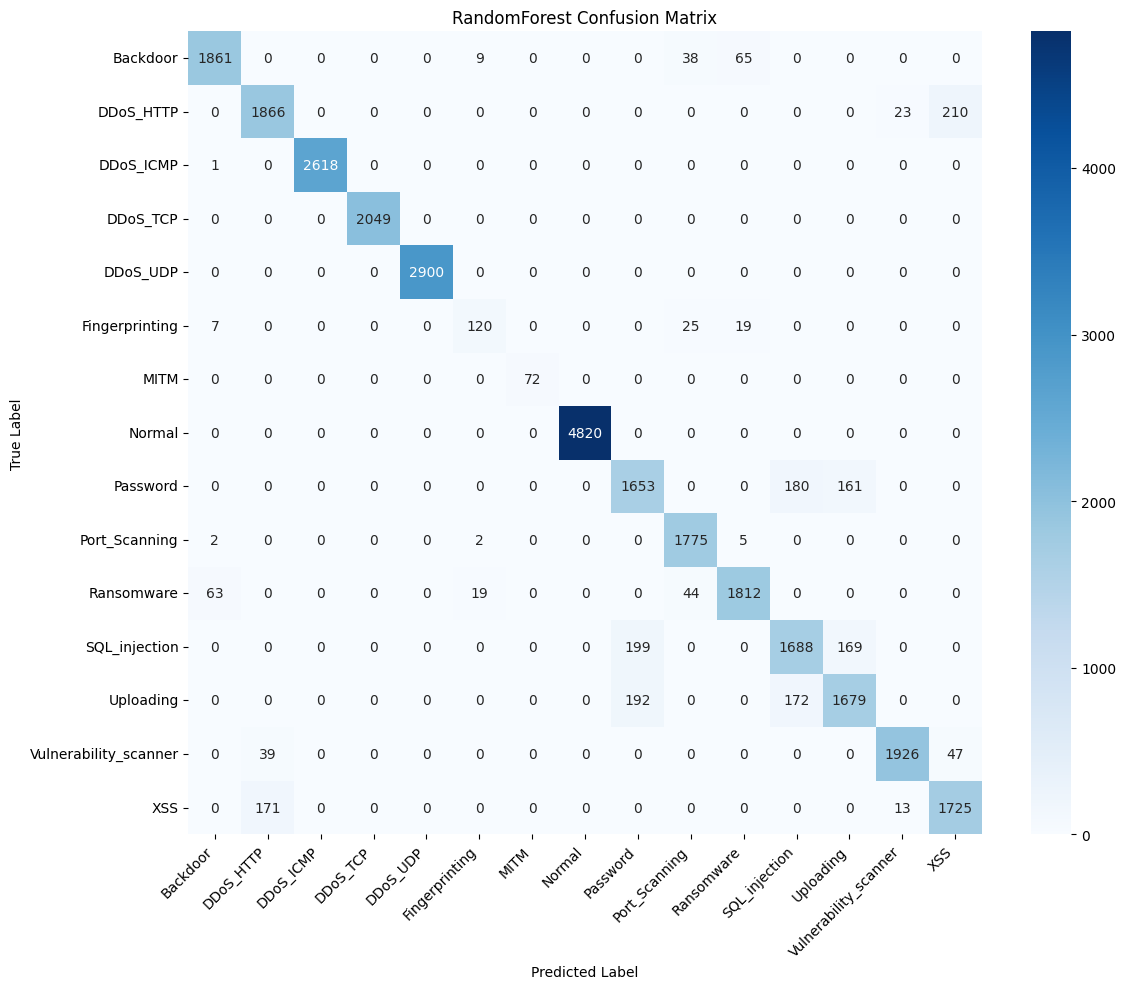


EVALUATION COMPLETE


In [8]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

models_baseline = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0, thread_count=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),

}

results_baseline = evaluate_models(models_baseline, X_train, y_train, X_val, y_val, labels_ml)

# Ensemble Classifiers
Questions to answer:
1. Does combining our existing models in an ensemble improve performance?
2. Stacking or voting?
3. If stacking, which model performs the best as a final estimator?


Training Voting Ensemble...

Voting Ensemble Validation Set Results:
  Accuracy:         0.9455
  Precision Macro:  0.9394
  Precision Weight: 0.9458
  Recall Macro:     0.9260
  Recall Weight:    0.9455
  F1 Macro:         0.9315
  F1 Weight:        0.9454

Voting Ensemble Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.97      0.94      0.96      1973
            DDoS_HTTP       0.90      0.95      0.93      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.91      0.69      0.78       171
                 MITM       1.00      1.00      1.00        72
               Normal       1.00      1.00      1.00      4820
             Password       0.83      0.82      0.83      1994
        Port_Scanning       0.94      1.00      0.97      1784
       

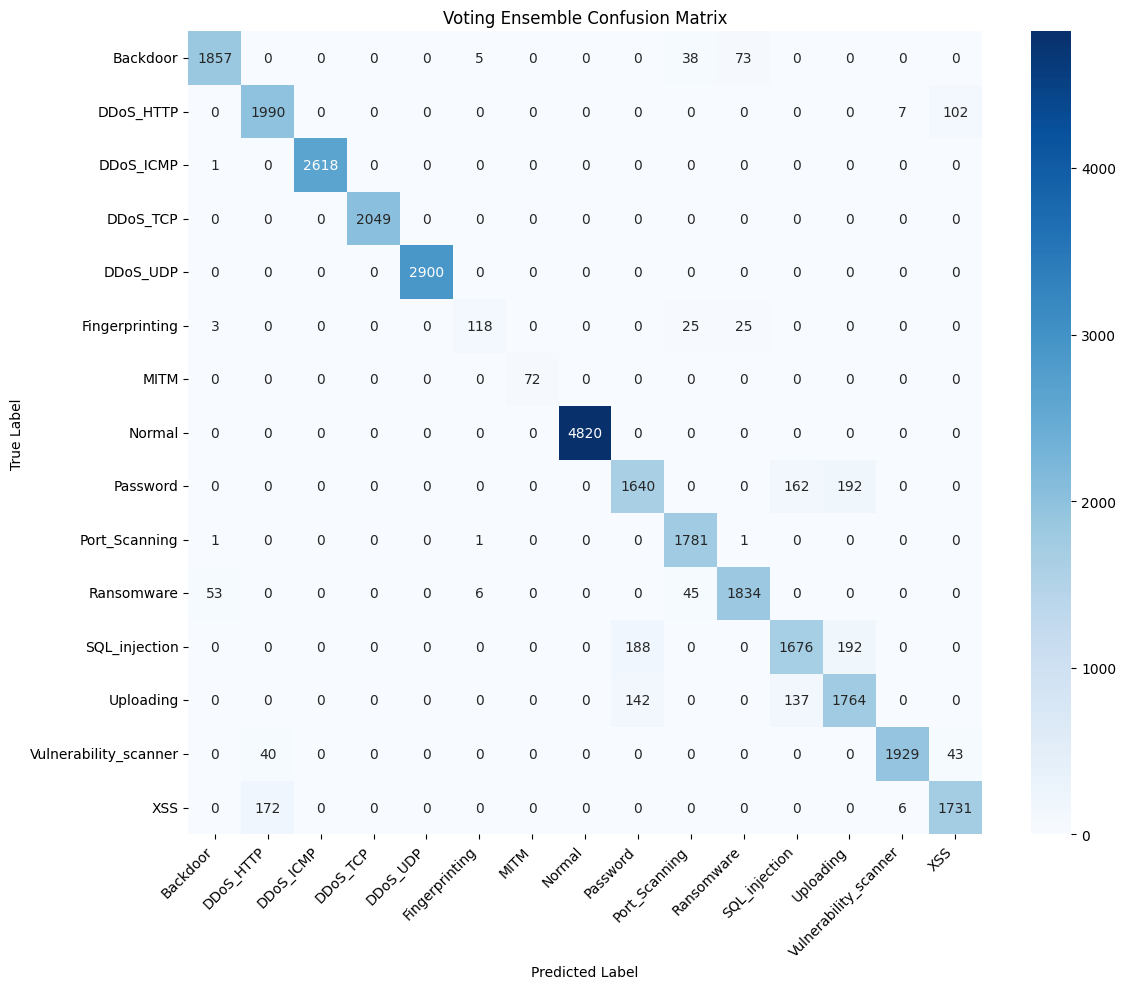


Training Stacking Ensemble (XGB)...

Stacking Ensemble (XGB) Validation Set Results:
  Accuracy:         0.9431
  Precision Macro:  0.9373
  Precision Weight: 0.9456
  Recall Macro:     0.9226
  Recall Weight:    0.9431
  F1 Macro:         0.9280
  F1 Weight:        0.9431

Stacking Ensemble (XGB) Classification Report:
                       precision    recall  f1-score   support

             Backdoor       0.98      0.93      0.96      1973
            DDoS_HTTP       0.85      0.97      0.91      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      1.00      1.00      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.87      0.69      0.77       171
                 MITM       1.00      0.99      0.99        72
               Normal       1.00      1.00      1.00      4820
             Password       0.77      0.88      0.82      1994
        Port_Scanning       0.94      1.00    

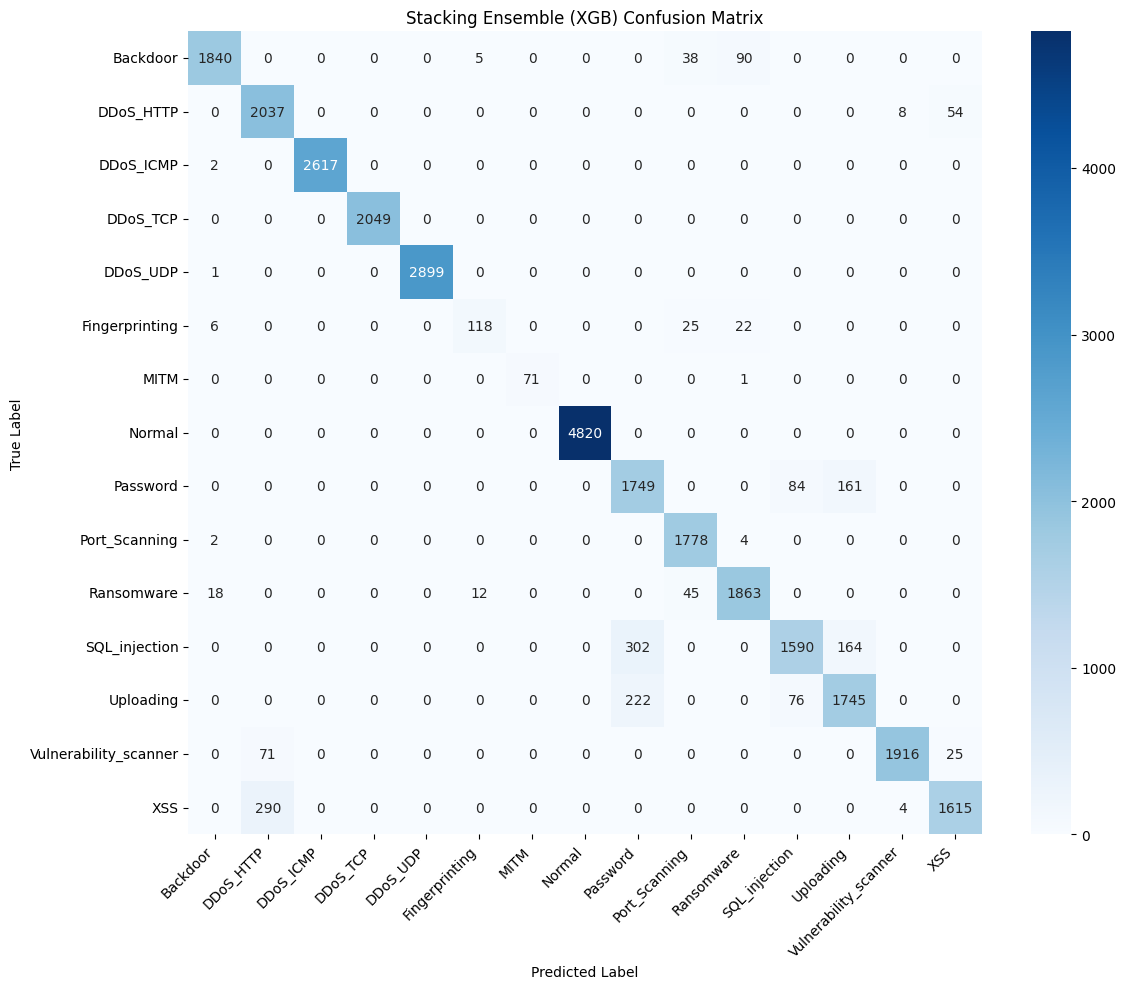


EVALUATION COMPLETE


In [9]:
from sklearn.ensemble import VotingClassifier, StackingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier

voting_model = VotingClassifier(
    estimators=[
        ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)),
        # ('cat', CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)), NOTE: errors with sklearn tags in ensemble, temporarily removed
        ('lgbm', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
    ],
    voting='soft'
)

stacking_model_xgb = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)),
        # ('cat', CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)), NOTE: errors with sklearn tags in ensemble, temporarily removed
        ('lgbm', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
    ],
    final_estimator=XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
)

models_ensemble = {
    "Voting Ensemble": voting_model,
    "Stacking Ensemble (XGB)": stacking_model_xgb
}

results_ensemble = evaluate_models(models_ensemble, X_train, y_train, X_val, y_val, labels_ml)

# Results:
**CatBoost** appears as the best performing model, although hard to tell due to the fact I cannot get catboost to work in sklearn ensemble classifiers.

Across the board, it seems like the worst performing class is **Fingerprinting**, next steps likely involve adjusting preprocessing to improve performance in that class.

# Investigating Fingerprinting Predictions

`Fingerprinting` is getting misclassified as `Port_Scanning` or `Ransomware` by all models.

Plotting UMAP of all classes to see if this is an issue with seperability

### UMAP Clusters

In [10]:
!pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/tmp/ipykernel_1170/332294322.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(classes))


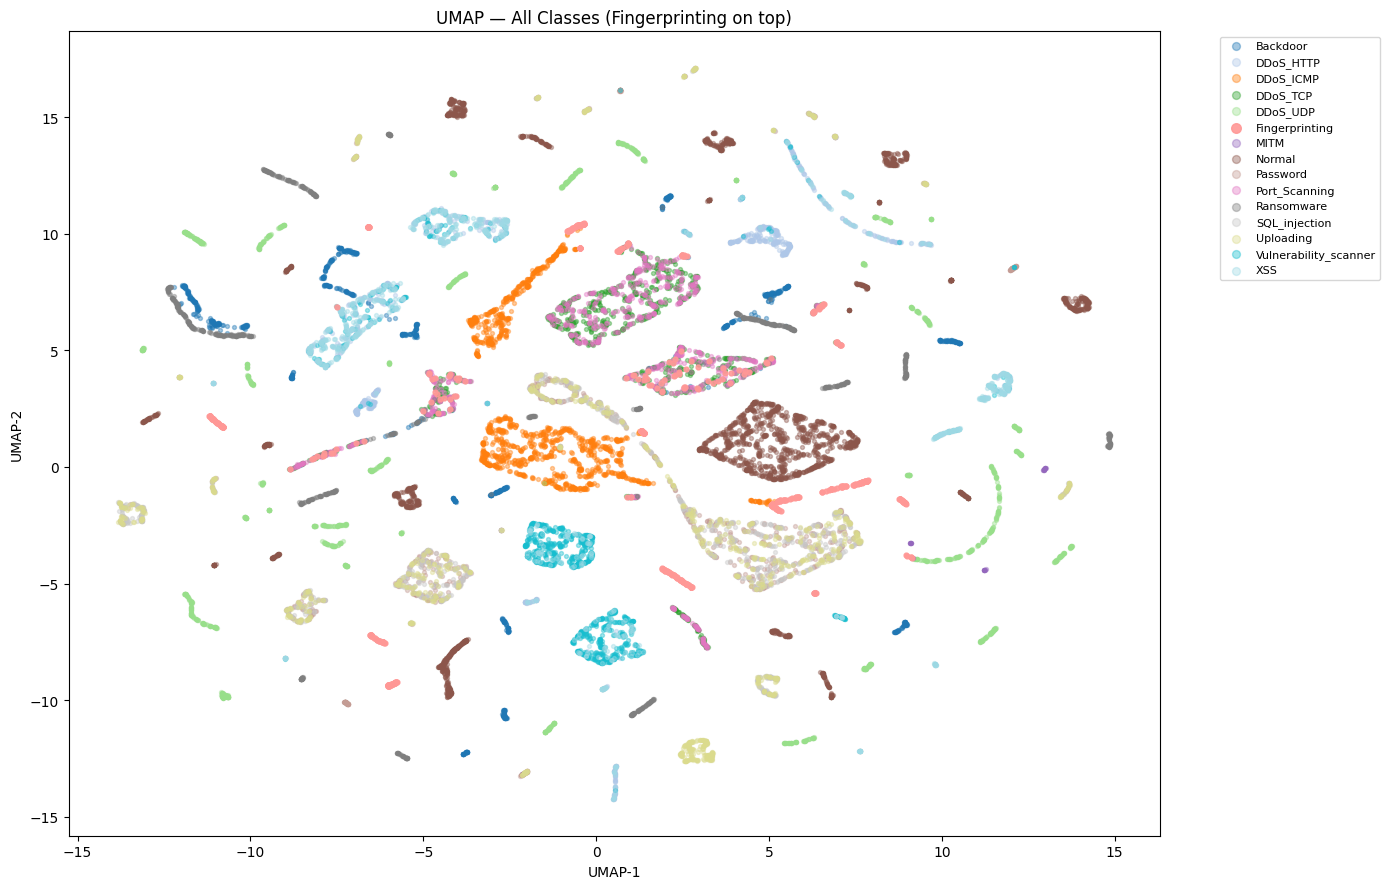

In [11]:
import umap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y_train_decoded = y_train.map({int(k): v for k, v in labels_ml.items()})

target_class = 'Fingerprinting'

fp_mask = y_train_decoded == target_class
X_fp = X_train[fp_mask]
y_fp = y_train_decoded[fp_mask]

n_other = min(15000, (~fp_mask).sum())
X_other = X_train[~fp_mask].sample(n=n_other, random_state=42)
y_other = y_train_decoded[~fp_mask].sample(n=n_other, random_state=42)

X_sample = pd.concat([X_fp, X_other])
y_sample = pd.concat([y_fp, y_other])

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_sample)

X_vis, y_vis = X_umap, y_sample.values

# Assign a distinct color to each class
classes = np.unique(y_vis)
cmap = plt.cm.get_cmap('tab20', len(classes))
color_map = {cls: cmap(i) for i, cls in enumerate(classes)}

fig, ax = plt.subplots(figsize=(14, 9))

# Plot all classes including Fingerprinting with consistent styling
for cls in classes:
    mask = y_vis == cls
    zorder = 5 if cls == target_class else 1
    size = 12 if cls == target_class else 8
    alpha = 0.9 if cls == target_class else 0.4
    ax.scatter(
        X_vis[mask, 0], X_vis[mask, 1],
        color=color_map[cls], alpha=alpha, s=size,
        label=cls, zorder=zorder
    )

ax.set_title('UMAP — All Classes (Fingerprinting on top)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

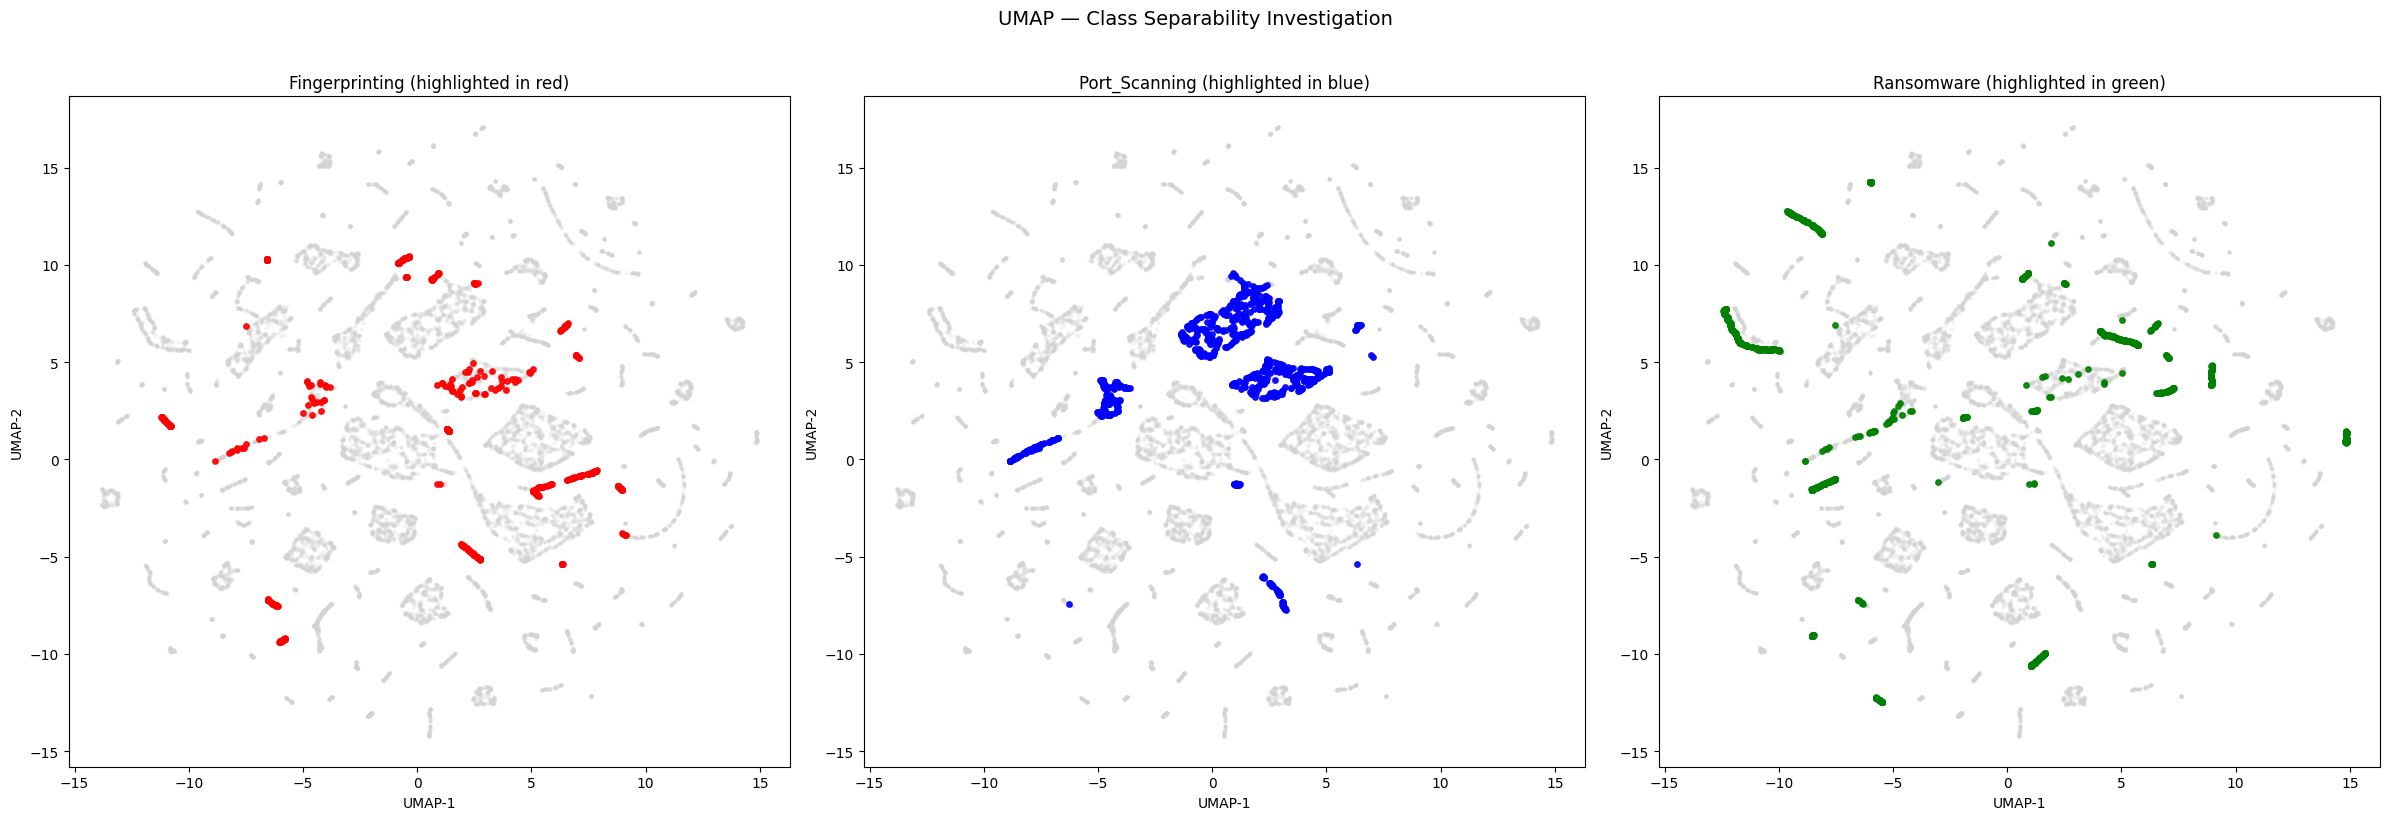

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

hardcoded_colors = {
    'Fingerprinting': 'red',
    'Port_Scanning': 'blue',
    'Ransomware': 'green'
}

for ax, (focus_class, focus_color) in zip(axes, hardcoded_colors.items()):
    for cls in classes:
        mask = y_vis == cls
        is_focus = cls == focus_class
        ax.scatter(
            X_vis[mask, 0], X_vis[mask, 1],
            color=focus_color if is_focus else 'lightgrey',
            alpha=0.9 if is_focus else 0.2,
            s=15 if is_focus else 4,
            label=cls if is_focus else None,
            zorder=5 if is_focus else 1
        )
    ax.set_title(f'{focus_class} (highlighted in {focus_color})')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')

plt.suptitle('UMAP — Class Separability Investigation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### UMAP Findings
From the above plots, it's clear why `Fingerprinting` is getting misclassified, as the large majority of the `Fingerprinting` UMAP clusters overlap with `Port_Scanning` and `Ransomware`

Fixing this will likely require feature engineering

### Feature Importance

As `Catboost` performed the best on `Fingerprinting`, will use `Catboost` model to investigate which features prominently denote `Fingerprinting` vs. the other classes it overlaps with.

In [13]:
# Which features does the best performing model on Fingerprinting care the most about?
from catboost import CatBoostClassifier
cat = CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)
cat.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

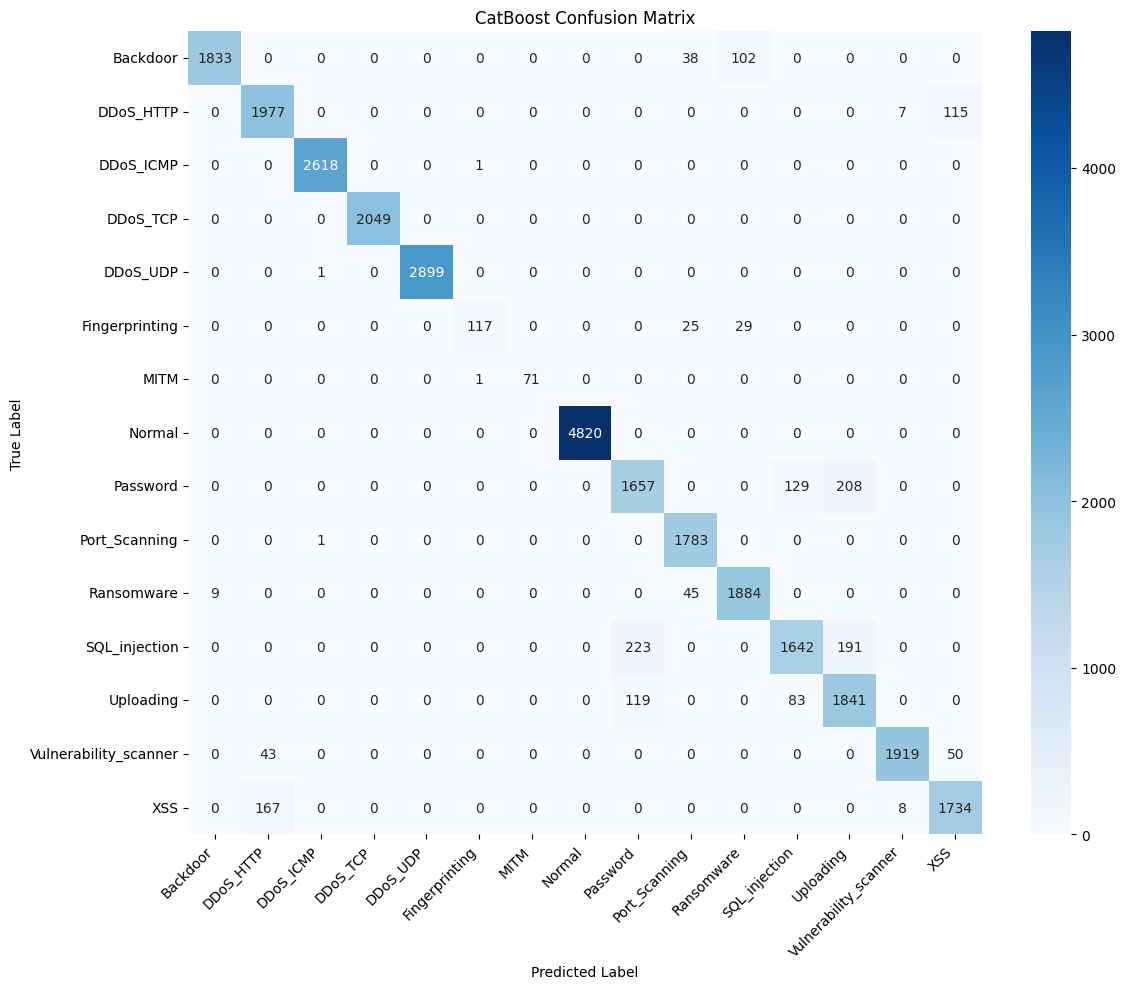

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = cat.predict(X_val)

cm = confusion_matrix(y_val, y_pred)
target_names = [labels_ml[i] for i in sorted(labels_ml.keys())]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'CatBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

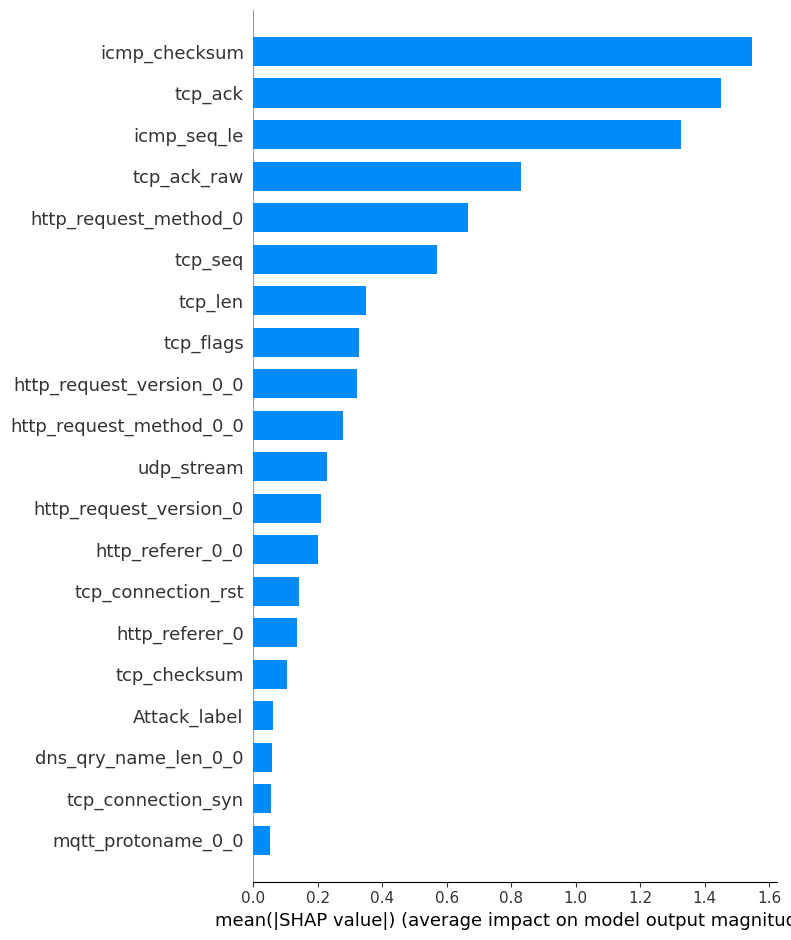

In [15]:
import shap
explainer = shap.TreeExplainer(cat)

fingerprint_label = [key for key, value in labels_ml.items() if value == 'Fingerprinting'][0]
shap_values = explainer.shap_values(X_val[y_val == fingerprint_label])

# Handle CatBoost's 3D shap output (n_samples, n_features, n_classes)
if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
    sv = shap_values[:, :, fingerprint_label]
else:
    sv = shap_values[fingerprint_label]

shap.summary_plot(sv,
                  X_val[y_val == fingerprint_label],
                  feature_names=X_train.columns,
                  plot_type="bar")

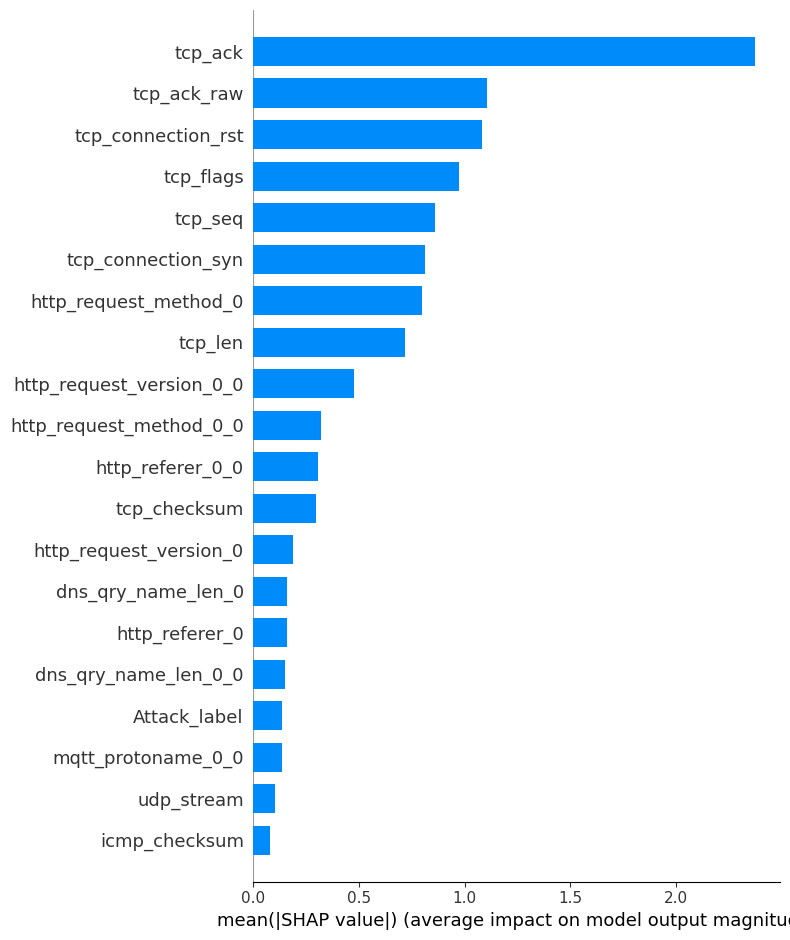

In [16]:
port_scanning_label = [key for key, value in labels_ml.items() if value == 'Port_Scanning'][0]
shap_values = explainer.shap_values(X_val[y_val == port_scanning_label])

# Handle CatBoost's 3D shap output (n_samples, n_features, n_classes)
if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
    sv = shap_values[:, :, port_scanning_label]
else:
    sv = shap_values[port_scanning_label]

shap.summary_plot(sv,
                  X_val[y_val == port_scanning_label],
                  feature_names=X_train.columns,
                  plot_type="bar")

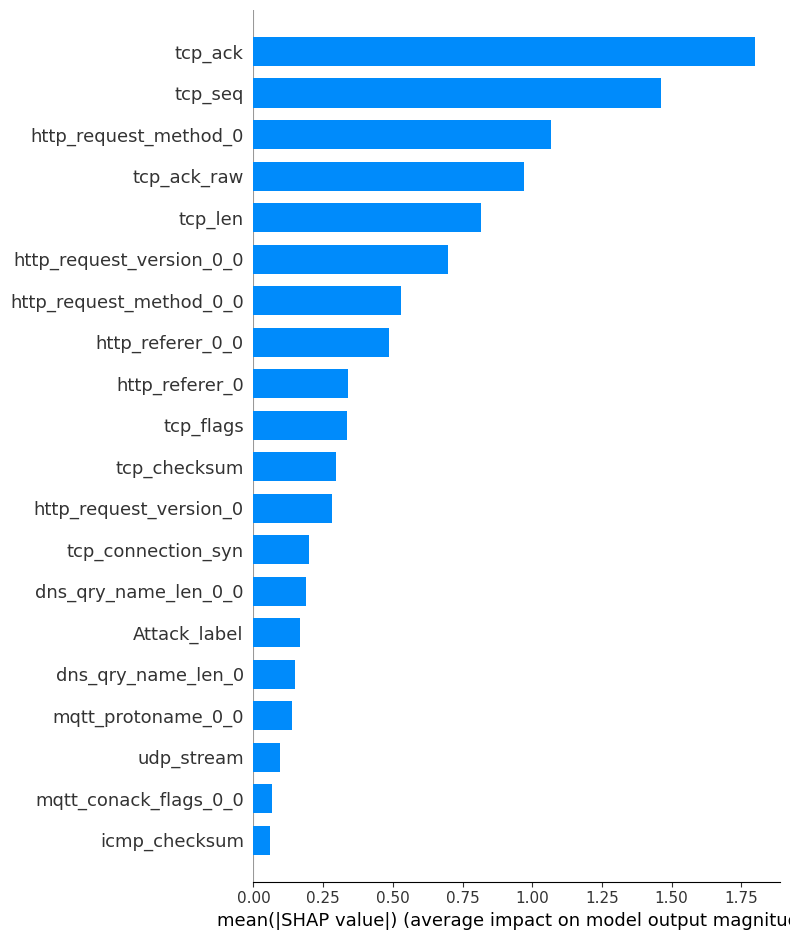

In [17]:
ransomware_label = [key for key, value in labels_ml.items() if value == 'Ransomware'][0]
shap_values = explainer.shap_values(X_val[y_val == ransomware_label])

# Handle CatBoost's 3D shap output (n_samples, n_features, n_classes)
if hasattr(shap_values, 'shape') and len(shap_values.shape) == 3:
    sv = shap_values[:, :, ransomware_label]
else:
    sv = shap_values[ransomware_label]

shap.summary_plot(sv,
                  X_val[y_val == ransomware_label],
                  feature_names=X_train.columns,
                  plot_type="bar")

### SHAP Plot Findings:
All classes seem to have `tcp_ack` and `tcp_ack_raw` as highly significant features, likely contributing to the overlap

For `Fingerprinting`, most signfificant features are `icmp_checksum` and `icmp_seq_le`.


**Ideas:**
- Create interaction features between `icmp_checksum` and `icmp_seq_le`
- Shared TCP features are likely causing the overap, engineer `Fingerprinting`-specific feature capturing combination of ICMP and TCP patterns

## Deep Learning

Unfortunately, deep learning seems to be much worse than any DT/boosting based method. This is probably because the data is tabular



## Classic DNN

First we try a basic fully connected deep neural network


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# class imbalance handler
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

# dnn architecture
model = Sequential([
    # inputs
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(len(np.unique(y_train)), activation='softmax')
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

print("Training Deep Neural Network...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import classification_report
target_names = [labels_ml[i] for i in sorted(labels_ml.keys())]
print(classification_report(y_val, y_pred_classes, target_names=target_names))

Training Deep Neural Network...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


357/357 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6335 - loss: 0.9770 - val_accuracy: 0.7091 - val_loss: 0.5406
Epoch 2/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7136 - loss: 0.5651 - val_accuracy: 0.7513 - val_loss: 0.5154
Epoch 3/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7300 - loss: 0.5343 - val_accuracy: 0.7435 - val_loss: 0.4903
Epoch 4/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7779 - loss: 0.4662 - val_accuracy: 0.7912 - val_loss: 0.4499
Epoch 5/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7896 - loss: 0.4304 - val_accuracy: 0.7922 - val_loss: 0.4373
Epoch 6/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7959 - loss: 0.4150 - val_accuracy: 0.8089 - val_loss: 0.4099
Epoch 7/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8041 - loss: 0.3962 - val_accuracy: 0.8091 - val_loss: 0.4031
Epoch 8/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8061 - loss: 0.3952 - val_accuracy: 0.79

## CNN

Next we will try a CNN based method, and see if this will understand relationships between features better.



In [38]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Conv1D, GlobalMaxPooling1D, Flatten, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# class weights, except clip them so we don't overfocus on small classes
raw_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

clipped_weights = np.clip(raw_class_weights, a_min=0.2, a_max=5.0)
class_weight_dict = dict(enumerate(clipped_weights))

# dnn architecture
inputs = Input(shape=(X_train.shape[1],))

x = Reshape((X_train.shape[1], 1))(inputs)

x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = GlobalMaxPooling1D()(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(len(np.unique(y_train)), activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

print("Training 1D-CNN Model...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


y_pred_probs = model.predict(X_val)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import classification_report
target_names = [labels_ml[i] for i in sorted(labels_ml.keys())]
print(classification_report(y_val, y_pred_classes, target_names=target_names))

Training 1D-CNN Model...
Epoch 1/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.5816 - loss: 1.1696 - val_accuracy: 0.1329 - val_loss: 5.1047 - learning_rate: 0.0010
Epoch 2/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7190 - loss: 0.6384 - val_accuracy: 0.6811 - val_loss: 0.7590 - learning_rate: 0.0010
Epoch 3/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7666 - loss: 0.5292 - val_accuracy: 0.7693 - val_loss: 0.4768 - learning_rate: 0.0010
Epoch 4/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7747 - loss: 0.5039 - val_accuracy: 0.7754 - val_loss: 0.4622 - learning_rate: 0.0010
Epoch 5/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7842 - loss: 0.4770 - val_accuracy: 0.8031 - val_loss: 0.4204 - learning_rate: 0.0010
Epoch 6/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7956 - loss: 0.4447 - val_accuracy: 0.7970 - val_loss: 0.4326 - learning_rate: 0.0010
Epoch 7/100
357/357 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - 

## TabNet

DNN and CNNs are notoriously much worse on tabular data. Google created TabNet, which seeks to use deep learning on tabular datasets.

In [39]:
!pip install pytorch-tabnet

In [36]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import numpy as np
from sklearn.metrics import classification_report

# TabNet requires numpy arrays
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
X_val_np = X_val.values if hasattr(X_val, 'values') else X_val
y_val_np = y_val.values if hasattr(y_val, 'values') else y_val


clf = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.0, n_independent=2, n_shared=2,

    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),

    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,

    # entmax forces sparse feature selection, which is similar to
    # the way DT based methods work
    mask_type='entmax',
    device_name='cuda' if torch.cuda.is_available() else 'cpu'
)

print("Training TabNet...")


clf.fit(
    X_train=X_train_np, y_train=y_train_np,
    eval_set=[(X_val_np, y_val_np)],
    eval_name=['valid'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128,
    weights=1
)


y_pred_classes = clf.predict(X_val_np)

target_names = [labels_ml[i] for i in sorted(labels_ml.keys())]
print("\nClassification Report for TabNet:")
print(classification_report(y_val_np, y_pred_classes, target_names=target_names))

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Training TabNet...
epoch 0  | loss: 0.89508 | valid_accuracy: 0.71904 |  0:00:07s
epoch 1  | loss: 0.52293 | valid_accuracy: 0.7247  |  0:00:15s
epoch 2  | loss: 0.48522 | valid_accuracy: 0.77572 |  0:00:22s
epoch 3  | loss: 0.45331 | valid_accuracy: 0.74257 |  0:00:30s
epoch 4  | loss: 0.43588 | valid_accuracy: 0.81014 |  0:00:37s
epoch 5  | loss: 0.42064 | valid_accuracy: 0.79454 |  0:00:45s
epoch 6  | loss: 0.41758 | valid_accuracy: 0.75942 |  0:00:52s
epoch 7  | loss: 0.42118 | valid_accuracy: 0.81317 |  0:01:00s
epoch 8  | loss: 0.41219 | valid_accuracy: 0.77217 |  0:01:07s
epoch 9  | loss: 0.41721 | valid_accuracy: 0.79878 |  0:01:14s
epoch 10 | loss: 0.41008 | valid_accuracy: 0.76694 |  0:01:22s
epoch 11 | loss: 0.4101  | valid_accuracy: 0.80949 |  0:01:29s
epoch 12 | loss: 0.40214 | valid_accuracy: 0.78209 |  0:01:37s
epoch 13 | loss: 0.40431 | valid_accuracy: 0.81501 |  0:01:44s
epoch 14 | loss: 0.40145 | valid_accuracy: 0.7928  |  0:01:52s
epoch 15 | loss: 0.3997  | valid_acc

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Classification Report for TabNet:
                       precision    recall  f1-score   support

             Backdoor       1.00      0.90      0.95      1973
            DDoS_HTTP       0.87      0.59      0.70      2099
            DDoS_ICMP       1.00      1.00      1.00      2619
             DDoS_TCP       1.00      0.58      0.73      2049
             DDoS_UDP       1.00      1.00      1.00      2900
       Fingerprinting       0.41      0.85      0.55       171
                 MITM       1.00      1.00      1.00        72
               Normal       1.00      1.00      1.00      4820
             Password       0.90      0.17      0.29      1994
        Port_Scanning       0.65      1.00      0.78      1784
           Ransomware       0.95      0.91      0.93      1938
        SQL_injection       0.43      0.89      0.58      2056
            Uploading       0.71      0.52      0.60      2043
Vulnerability_scanner       0.95      0.86      0.90      2012
                  X

## Tabular Resnet

The following is a custom implementation of TabNet with residual connections.

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import numpy as np
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_tensor = torch.tensor(X_train.values if hasattr(X_train, 'values') else X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values if hasattr(y_train, 'values') else y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val.values if hasattr(X_val, 'values') else X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values if hasattr(y_val, 'values') else y_val, dtype=torch.long)

batch_size = 512
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


raw_class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
clipped_weights = np.clip(raw_class_weights, a_min=0.2, a_max=5.0)
class_weights_tensor = torch.tensor(clipped_weights, dtype=torch.float32).to(device)

# tabular resnet (with skip connections)
class TabularResNetBlock(nn.Module):
    def __init__(self, dim, dropout_rate=0.3):
        super(TabularResNetBlock, self).__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.dropout = nn.Dropout(dropout_rate)
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x

        out = self.bn1(self.fc1(x))
        out = self.relu(out)
        out = self.dropout(out)

        out = self.bn2(self.fc2(out))

        out += residual
        out = self.relu(out)
        return out

class EdgeIIoT_ResNet(nn.Module):
    def __init__(self, num_features, num_classes, hidden_dim=256, num_blocks=4):
        super(EdgeIIoT_ResNet, self).__init__()

        self.initial_layer = nn.Sequential(
            nn.Linear(num_features, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

        self.blocks = nn.ModuleList([
            TabularResNetBlock(hidden_dim, dropout_rate=0.3) for _ in range(num_blocks)
        ])

        self.head = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.initial_layer(x)
        for block in self.blocks:
            x = block(x)
        logits = self.head(x)
        return logits

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))
model = EdgeIIoT_ResNet(num_features, num_classes, hidden_dim=256, num_blocks=4).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5)

epochs = 100
patience = 15
best_val_loss = float('inf')
patience_counter = 0
best_model_weights = copy.deepcopy(model.state_dict())

print("Training Tabular ResNet...")
for epoch in range(epochs):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader.dataset)
    train_accuracy = 100 * train_correct / train_total
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Accuracy: {train_accuracy}")

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader.dataset)
    val_accuracy = 100 * val_correct / val_total
    print(f"Epoch {epoch+1}/{epochs} - Val Loss: {val_loss:.4f}, Accuracy: {val_accuracy}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}.")
            break

model.load_state_dict(best_model_weights)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

target_names = [labels_ml[i] for i in sorted(labels_ml.keys())]
print("\nClassification Report on Best Tabular ResNet:")
print(classification_report(all_labels, all_preds, target_names=target_names))

Using device: cuda
Training Tabular ResNet...
Epoch 1/100 - Train Loss: 0.7023, Accuracy: 70.23555307335984
Epoch 1/100 - Val Loss: 0.6004, Accuracy: 73.43868063996847
Epoch 2/100 - Train Loss: 0.6106, Accuracy: 72.96231807878051
Epoch 2/100 - Val Loss: 0.5645, Accuracy: 73.84276750221755
Epoch 3/100 - Train Loss: 0.5452, Accuracy: 77.1137904223748
Epoch 3/100 - Val Loss: 0.4741, Accuracy: 80.67610631098262
Epoch 4/100 - Train Loss: 0.4798, Accuracy: 79.71681067052137
Epoch 4/100 - Val Loss: 0.4534, Accuracy: 80.86336607641512
Epoch 5/100 - Train Loss: 0.4491, Accuracy: 80.84693978120175
Epoch 5/100 - Val Loss: 0.5186, Accuracy: 77.94934130556194
Epoch 6/100 - Train Loss: 0.4421, Accuracy: 80.96082876134783
Epoch 6/100 - Val Loss: 0.4204, Accuracy: 81.67153980091331
Epoch 7/100 - Train Loss: 0.4331, Accuracy: 81.43390606349311
Epoch 7/100 - Val Loss: 0.6363, Accuracy: 75.50182331876869
Epoch 8/100 - Train Loss: 0.4275, Accuracy: 81.49413581260882
Epoch 8/100 - Val Loss: 0.8990, Accurac